TensorFlow: 2.19.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 111ms/step - accuracy: 0.3577 - loss: 1.7506 - val_accuracy: 0.5094 - val_loss: 1.3770
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 116ms/step - accuracy: 0.4869 - loss: 1.4258 - val_accuracy: 0.5698 - val_loss: 1.2153
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.5328 - loss: 1.3021 - val_accuracy: 0.6202 - val_loss: 1.1151
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.5676 - loss: 1.2164 - val_accuracy: 0.6410 - val_loss: 1.0307
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.5867 - loss: 1.1593 - val_accuracy: 0.6500 - val_loss: 1.0215
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 111ms/step - accuracy: 0.6027 - loss: 1.1150 - val_accuracy: 0.6692 - val_loss: 0.9663
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 110ms/step - accuracy: 0.6215 - loss: 1.0723 - val_accuracy: 0.6820 - val_loss: 0.9307
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 111ms/step - accuracy: 0.6310 - loss: 1

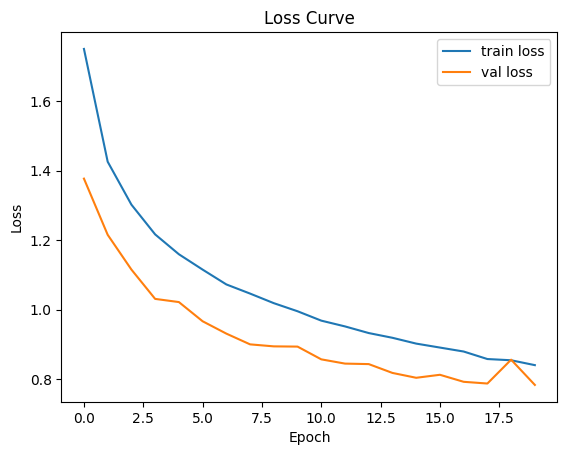

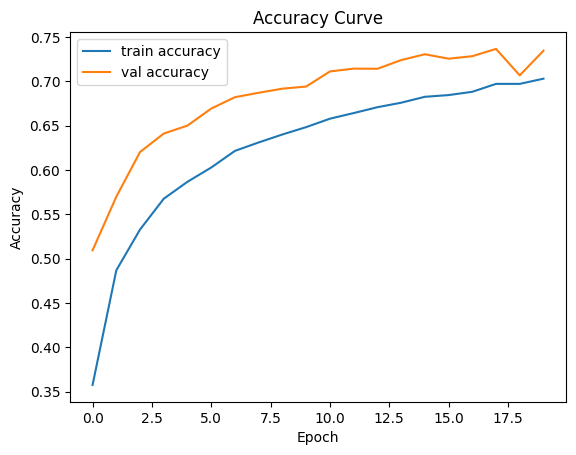

<Figure size 1000x1000 with 0 Axes>

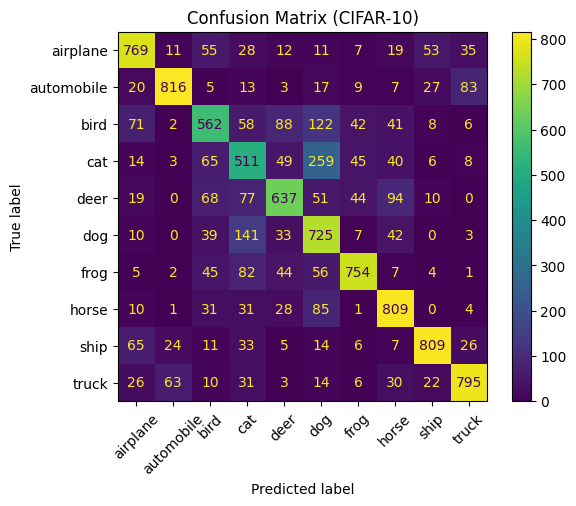

In [ ]:
# =========================
# AI100 Midterm: CIFAR-10 Simple CNN (TensorFlow/Keras)
# =========================
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
os.makedirs("figures", exist_ok=True)

# 1) Load CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

# 2) Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# 3) Build a very simple CNN
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# 4) Train (set to 5 first; later change to 15)
EPOCHS = 20
BATCH_SIZE = 64

history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# 5) Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# 6) Plot curves
plt.figure()
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.savefig("figures/loss.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.savefig("figures/accuracy.png", dpi=200, bbox_inches="tight")
plt.show()

# 7) Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test.reshape(-1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(10,10))
disp.plot(xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix (CIFAR-10)")
plt.savefig("figures/confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()